In [1]:
import os
import librosa
import soundfile as sf
import pandas as pd
import shutil
import numpy as np
from pathlib import Path
from glob import glob
import matplotlib.pyplot as plt
from tqdm import tqdm

from audiomentations import Compose, AddGaussianNoise, PitchShift, Shift, TimeStretch

In [2]:
sounds_df = pd.read_csv('datasets/UrbanSound8K/UrbanSound8K.csv')
sounds_df[sounds_df['classID'] == 0] 

,slice_file_name,fsID,start,end,salience,fold,classID,class
22,100852-0-0-0.wav,100852,0.0,4.0,1,5,0,air_conditioner
23,100852-0-0-1.wav,100852,0.5,4.5,1,5,0,air_conditioner
24,100852-0-0-10.wav,100852,5.0,9.0,1,5,0,air_conditioner
25,100852-0-0-11.wav,100852,5.5,9.5,1,5,0,air_conditioner
26,100852-0-0-12.wav,100852,6.0,10.0,1,5,0,air_conditioner
...,...,...,...,...,...,...,...,...
8307,85569-0-0-5.wav,85569,2.5,6.5,1,5,0,air_conditioner
8308,85569-0-0-6.wav,85569,3.0,7.0,1,5,0,air_conditioner
8309,85569-0-0-7.wav,85569,3.5,7.5,1,5,0,air_conditioner
8310,85569-0-0-8.wav,85569,4.0,8.0,1,5,0,air_conditioner


In [2]:
classes_dict = {
    0: 'air_conditioner',
    1: 'car_horn',
    2: 'children_playing',
    3: 'dog_bark',
    4: 'drilling',
    5: 'engine_idling',
    6: 'gun_shot',
    7: 'jackhammer',
    8: 'siren',
    9: 'street_music',
}

In [ ]:
# распределение по классам
source_dir = 'datasets/UrbanSound8K/'
output_dir = 'datasets/audio/'

os.makedirs(output_dir, exist_ok=True)

folders = [f'fold{i}' for i in range(1, 11)]

for folder in folders:
    folder_path = os.path.join(source_dir, folder)
    os.makedirs(folder_path, exist_ok=True)
    for filename in os.listdir(os.path.join(source_dir, folder)):
        if filename.endswith(".wav"):
            parts = filename.replace('.wav', '').split('-')

            if len(parts) >= 2:
                class_number = parts[1]

                class_dir = os.path.join(output_dir, f'class_{class_number}')
                os.makedirs(class_dir, exist_ok=True)

                src = os.path.join(folder_path, filename)
                dst = os.path.join(class_dir, filename)
                shutil.copy2(src, dst)

In [ ]:
# обрезка полезного сигнала (удаление тишины)
def remove_silence(y, sr, top_db=25, hop_lenght=512):
    # сигнал выше порога
    intervals = librosa.effects.split(y, top_db=top_db, hop_length=hop_lenght)
    # склейка фрагментов
    y_clean = np.concatenate([y[start:end] for start, end in intervals])
    return y_clean

path = output_dir

for fold in glob(os.path.join(path, 'class_*')):
    print(f'process folder {fold}') # debug
    for fpath in glob(os.path.join(fold, '*.wav')):
        y, sr = librosa.load(fpath, sr=None)
        y_clean = remove_silence(y, sr)

In [ ]:
# проверка распределения по классам
class_counts ={}

for class_folder in os.listdir(output_dir):
    class_path = os.path.join(output_dir, class_folder)
    count = len([f for f in os.listdir(class_path)])
    class_audio = classes_dict.get(int(class_folder.split('_')[-1]))
    class_counts[class_audio] = count

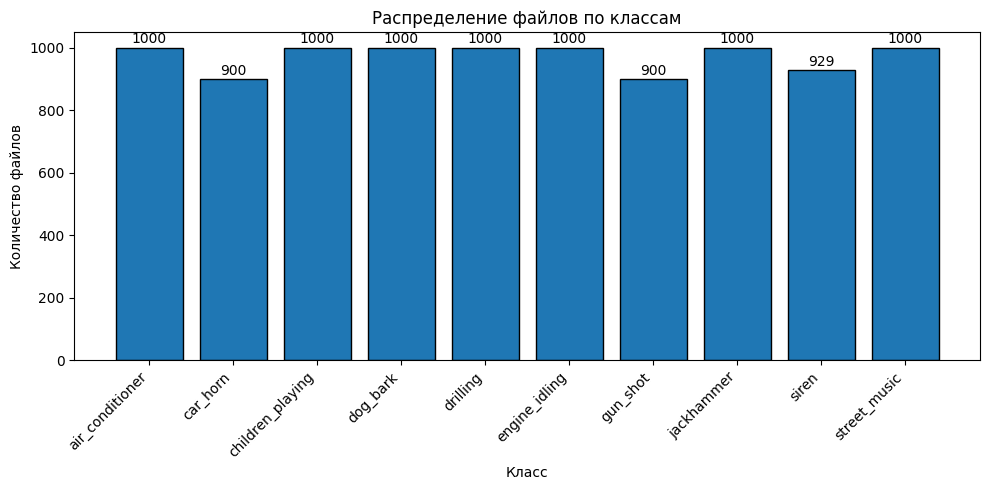

In [ ]:
classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, counts, edgecolor='black')

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=10)
    
plt.xlabel('Класс')
plt.ylabel('Количество файлов')
plt.title('Распределение файлов по классам')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

In [43]:
# выравнивание классов
target_count = 900
sr = 22050

augment = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.01, p=0.7),
    PitchShift(min_semitones=-2, max_semitones=2, p=0.5),
    TimeStretch(min_rate=0.9, max_rate=1.1, p=0.5),
    Shift(min_shift=-0.3, max_shift=0.3, p=0.5),
])

for class_name in os.listdir(output_dir):
    class_dir = os.path.join(output_dir, class_name)
    if not os.path.isdir(class_dir):
        continue

    files = [f for f in os.listdir(class_dir) if f.lower().endswith(".wav")]
    n_current = len(files)

    if n_current >= target_count:
        continue

    need = target_count - n_current

    i = 0
    while i < need:
        for fname in tqdm(files, desc=f'augment {class_name}'):
            if i >= need:
                break
            
            in_path = os.path.join(class_dir, fname)
            y, _ = librosa.load(in_path)
            y = y.astype(np.float32)

            y_aug = augment(samples=y, sample_rate=sr)

            base = os.path.splitext(fname)[0]
            out_name = f'{base}_aug_{i}.wav'
            out_path = os.path.join(class_dir, out_name)

            sf.write(out_path, y_aug, sr)

            i += 1

augment class_6:  41%|████      | 152/374 [00:01<00:02, 78.30it/s] 


___
___


In [4]:
import torch
import torch.nn as nn
import  torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
from torchaudio import transforms

import splitfolders

In [ ]:
#разделение на train vel test
os.mkdir('datasets/audio_split')
splitfolders.ratio('datasets/audio/', output='datasets/audio_split/', ratio=(0.7, 0.15, 0.15))

Copying files: 9729 files [00:39, 243.31 files/s] 


In [22]:
dataset_dir = output_dir
SAMPLE_RATE = 22050
NUM_MELS = 64
FIX_SECONDS = 4
FIX_LENGTH = SAMPLE_RATE * FIX_SECONDS

class AudioDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform

        self.resample = transforms.Resample(orig_freq=44100, new_freq=SAMPLE_RATE)
        self.mono = lambda x: torch.mean(x, dim=0, keepdim=True)

        self.filepaths = []
        self.labels = []

        class_names = sorted(
            d for d in os.listdir(data_dir)
            if os.path.isdir(os.path.join(data_dir, d))
        )
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}

        for cls_name in class_names:
            cls_folder = os.path.join(data_dir, cls_name)
            for fname in os.listdir(cls_folder):
                if fname.lower().endswith((".wav")):
                    path = os.path.join(cls_folder, fname)
                    self.filepaths.append(path)
                    self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.filepaths)
    
    def _pad_or_trim_waveform(self, waveform, target_length=FIX_LENGTH):
        num_samples = waveform.shape[1]
        if num_samples > target_length:
            waveform = waveform[:, :target_length]
        elif num_samples < target_length:
            pad_amount = target_length - num_samples
            waveform = torch.nn.functional.pad(waveform, (0, pad_amount))
        return waveform

    def __getitem__(self, idx):
        file_path = self.filepaths[idx]
        label = self.labels[idx]

        y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

        waveform = torch.from_numpy(y).unsqueeze(0)
        waveform = self._pad_or_trim_waveform(waveform)

        if self.transform:
            spec = self.transform(waveform)
        else:
            spec = waveform

        return spec, label

In [36]:
mel_transform = transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=1024,
    hop_length=512,
    n_mels=NUM_MELS,
    center=True,
    pad_mode='reflect'
)

dataset_dir = 'datasets/audio_split/'

train_ds = AudioDataset(dataset_dir + 'train', transform=mel_transform)
val_ds = AudioDataset(dataset_dir + 'val', transform=mel_transform)
test_ds = AudioDataset(dataset_dir + 'test', transform=mel_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

In [32]:
class AudioCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.gap = nn.AdaptiveAvgPool2d((8, 8))

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = self.gap(x)                        
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [40]:
device = 'cuda' if torch.cuda.is_available else 'cpu'

num_classes = len(train_ds.class_to_idx)

model = AudioCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [34]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for specs, labels in loader:
        specs = specs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(specs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * specs.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for specs, labels in loader:
            specs = specs.to(device)
            labels = labels.to(device)

            outputs = model(specs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * specs.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

In [46]:
num_epochs = 5

for epoch in tqdm(range(num_epochs)):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    print(
        f'Epoch {epoch + 1}\n'
        f'    train_loss={train_loss:.4f}, train_acc={train_acc:.3f}\n'
        f'    val_loss={val_loss:.4f}, val_acc={val_acc:.3f}'
    )


 20%|██        | 1/5 [01:02<04:08, 62.10s/it]

Epoch 1
    train_loss=0.6397, train_acc=0.864
    val_loss=1.4589, val_acc=0.760


 40%|████      | 2/5 [02:01<03:01, 60.65s/it]

Epoch 2
    train_loss=0.3202, train_acc=0.909
    val_loss=1.8101, val_acc=0.807


 60%|██████    | 3/5 [03:00<01:59, 59.92s/it]

Epoch 3
    train_loss=0.1975, train_acc=0.944
    val_loss=1.3453, val_acc=0.833


 80%|████████  | 4/5 [03:59<00:59, 59.60s/it]

Epoch 4
    train_loss=0.1260, train_acc=0.960
    val_loss=1.5398, val_acc=0.846


100%|██████████| 5/5 [04:59<00:00, 59.87s/it]

Epoch 5
    train_loss=0.1236, train_acc=0.963
    val_loss=1.5836, val_acc=0.838


In [43]:
from sklearn.metrics import classification_report

In [47]:
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for specs, labels in test_loader:
        specs = specs.to(device)
        outputs = model(specs)
        preds = outputs.argmax(dim=1).cpu().tolist()
        y_pred.extend(preds)
        y_true.extend(labels.tolist())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86       150
           1       0.84      0.93      0.88       135
           2       0.69      0.63      0.66       150
           3       0.73      0.84      0.78       150
           4       0.89      0.90      0.90       150
           5       0.87      0.92      0.90       150
           6       0.98      0.92      0.95       135
           7       0.94      0.91      0.93       150
           8       0.89      0.79      0.83       140
           9       0.74      0.74      0.74       150

    accuracy                           0.84      1460
   macro avg       0.85      0.84      0.84      1460
weighted avg       0.84      0.84      0.84      1460

